We are going to train a model that can predict whether a child has Kyphosis after their spinal surgery. We will be using a single decision tree and random forests. 

## Import Libraries

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Needed to hide warnings in the matplotlib sections
import warnings
warnings.filterwarnings("ignore")

## Get the Data
Now we import the data from the CSV file into a dataframe. The attributes of our set are the Age of the child (in months), the Number (of vertebrae) and the Start (top vertebra) operated on.

In [62]:
df = pd.read_csv('kyphosis.csv')

In [63]:
df.head()

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15


In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Kyphosis  81 non-null     str  
 1   Age       81 non-null     int64
 2   Number    81 non-null     int64
 3   Start     81 non-null     int64
dtypes: int64(3), str(1)
memory usage: 2.7 KB


In [65]:
df['Kyphosis'].value_counts()

Kyphosis
absent     64
present    17
Name: count, dtype: int64

## Train Test Split

Let's split up the data into a training set and a test set.

In [66]:
from sklearn.model_selection import train_test_split

In [67]:
X = df.drop('Kyphosis',axis=1) 
y = df['Kyphosis']
y

0      absent
1      absent
2     present
3      absent
4      absent
       ...   
76    present
77     absent
78     absent
79    present
80     absent
Name: Kyphosis, Length: 81, dtype: str

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

## Decision Trees

We'll start just by training a single decision tree.

Now we choose from sklearn.tree the decision tree classifier model

In [69]:
from sklearn.tree import DecisionTreeClassifier

Create a model called dtree. The default function to measure the quality of a split is the Gini impurity. You can change it if you wish to  be the entropy by passing in as a parameter when creating your model (criterion='entropy').

In [70]:
dtree = DecisionTreeClassifier(criterion='entropy')#(criterion='entropy')

Fit the model to the training data

In [71]:
dtree.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Prediction and Evaluation 

Let us evaluate now, how well our decision tree model is able to predict based on the attributes (Age, Number, Start), whether or not Kyphosis is present at the child or not.

In [72]:
predictions = dtree.predict(X_test)

sklearn.metrics provides the function confusion_matrix that compares the predicted values with the actual lable values, and outputs the confusion_matrix.

In [73]:
from sklearn.metrics import classification_report,confusion_matrix

In [74]:
comp_dt = pd.DataFrame({'dt_pred': predictions, 'y_test': y_test})

# Set the index of the DataFrame to the first column of y_test
comp_dt.set_index(y_test.index, inplace=True)

# Display the result
print(comp_dt)

    dt_pred   y_test
45  present  present
80   absent   absent
26   absent   absent
24   absent  present
34   absent   absent
67   absent   absent
68   absent   absent
48   absent  present
32   absent   absent
69   absent   absent
4    absent   absent
58  present   absent
7    absent   absent
23  present   absent
46   absent   absent
35   absent   absent
15   absent   absent
70   absent   absent
63   absent   absent
78   absent   absent
5    absent   absent
8    absent   absent
25   absent   absent
52   absent  present
17   absent   absent


In [75]:
print(confusion_matrix(y_test,predictions))

[[19  2]
 [ 3  1]]


Similarly, sklearn.metrics provides the function classification_report that outputs the main classification metrics: such as precision, recall, f1-score, accuracy, etc. You can read more about it in the sklearn documantation here https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

In [76]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

      absent       0.86      0.90      0.88        21
     present       0.33      0.25      0.29         4

    accuracy                           0.80        25
   macro avg       0.60      0.58      0.58        25
weighted avg       0.78      0.80      0.79        25



## Tree Visualization

Scikit learn actually has some built-in visualization capabilities for decision trees, you won't use this often and it requires you to install the pydot library, but here is an example of what it looks like and the code to execute this:

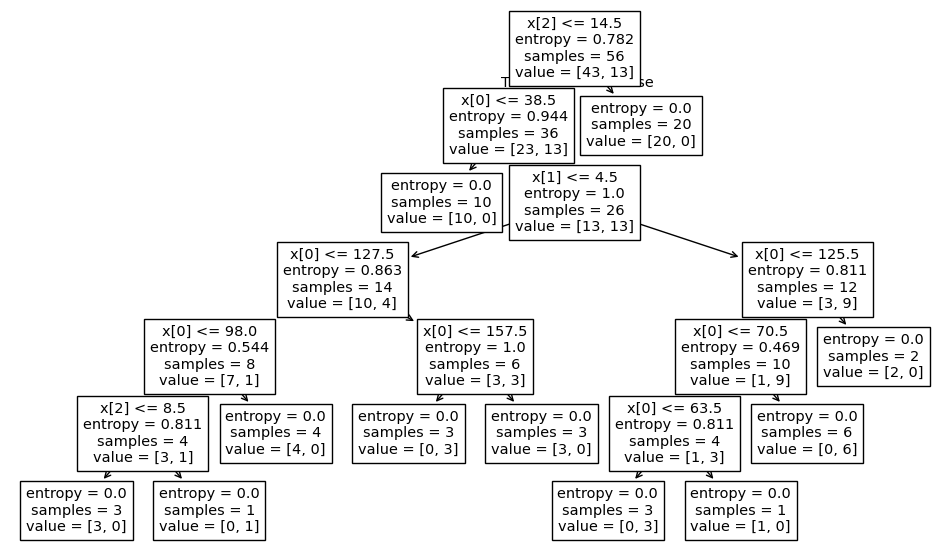

In [77]:
from sklearn import tree
fig, ax = plt.subplots(figsize=(12,7))  # whatever size you want
tree.plot_tree(dtree, ax=ax)
plt.show()


#### Tree visualisation using pydot 

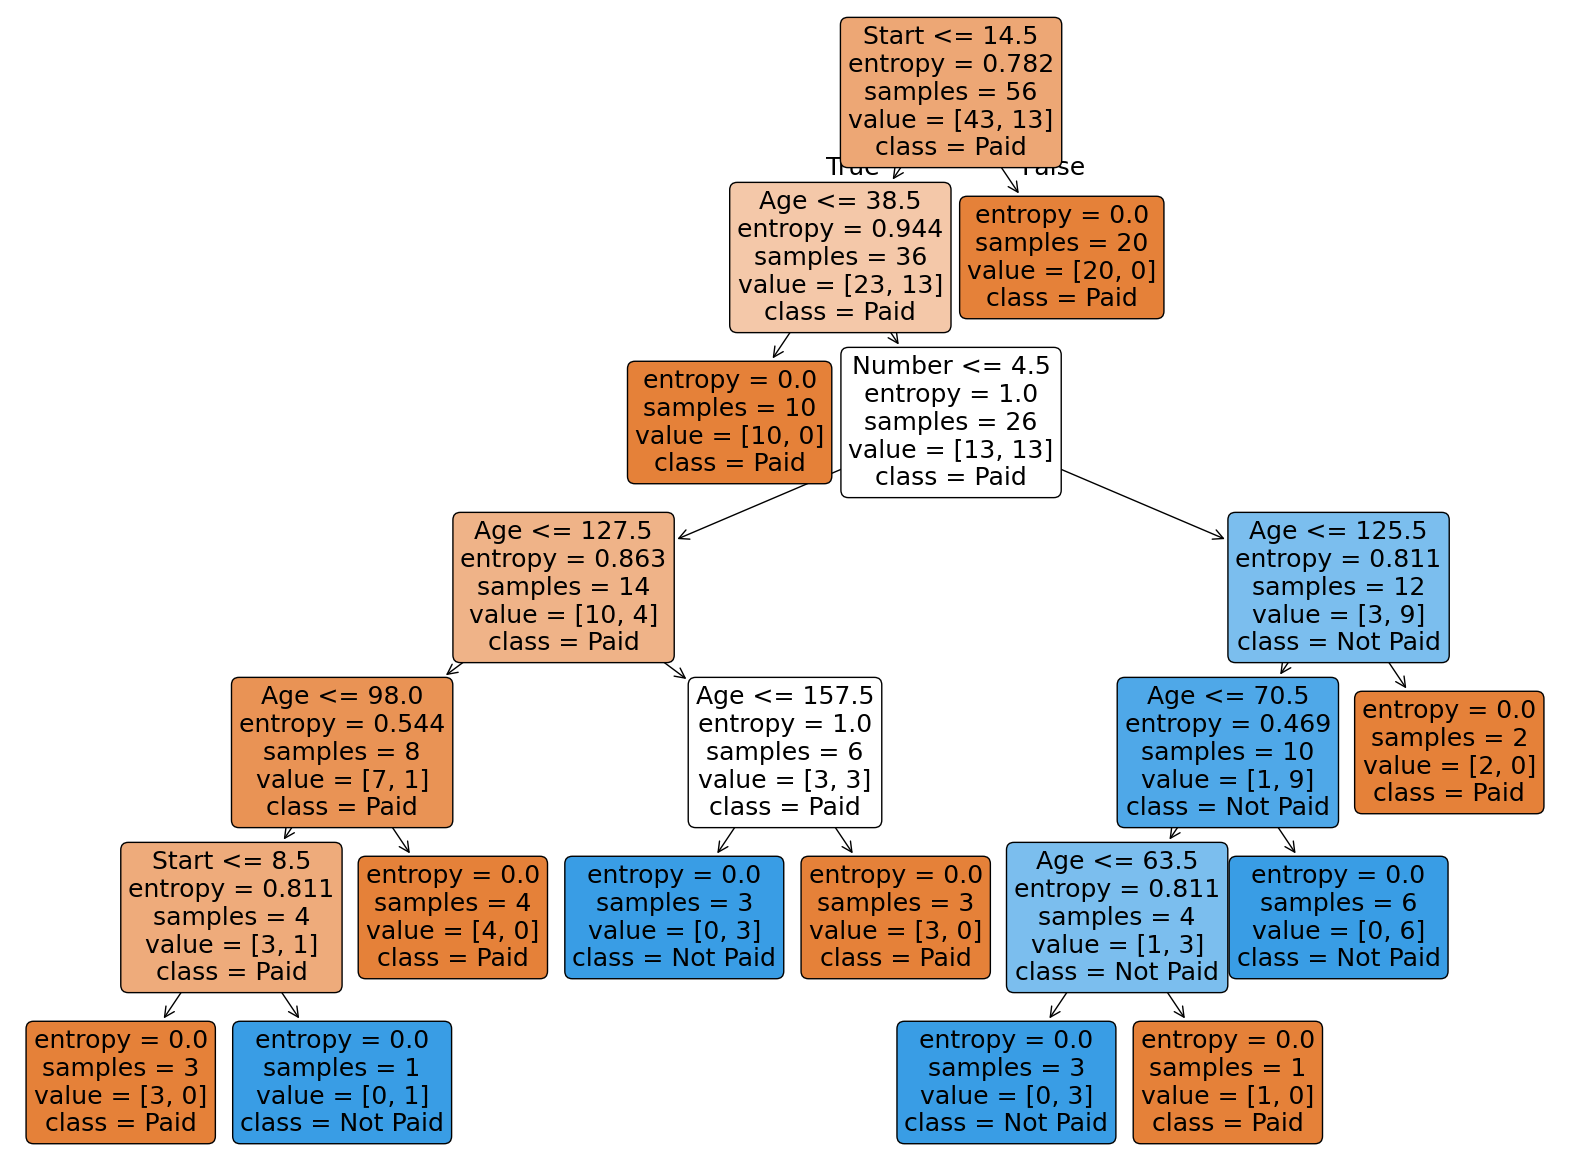

In [78]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 15))
plot_tree(dtree, feature_names=X_train.columns, class_names=['Paid', 'Not Paid'], filled=True, rounded=True)
plt.savefig('decision_tree.png')

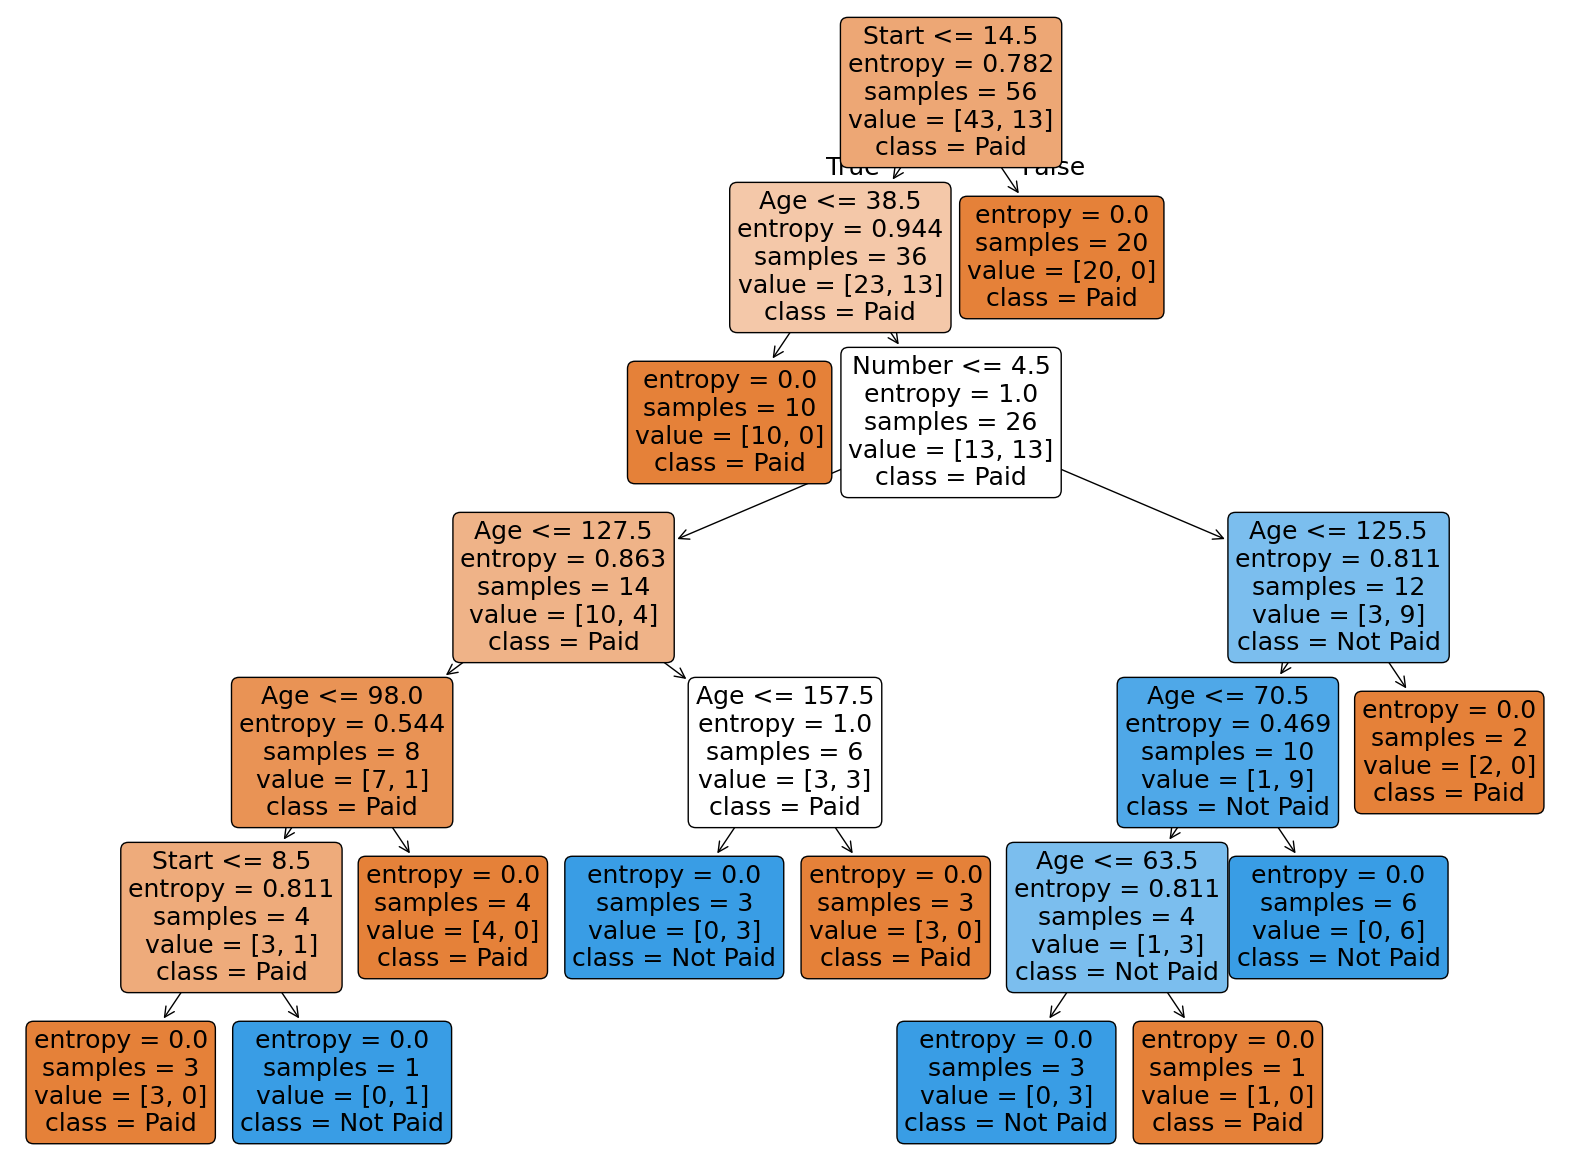

In [79]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 15))
plot_tree(dtree, feature_names=X_train.columns, class_names=['Paid', 'Not Paid'], filled=True, rounded=True)
plt.savefig('decision_tree.png', bbox_inches='tight')

## Random Forests

#### Now let's compare the decision tree model to a random forest.
A random forest is a meta estimator that fits a number of decision tree classifiers on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting. The sub-sample size is always the same as the original input sample size but the samples are drawn with replacement. You can read more about it here https://scikit-learn.org/stable/modules/ensemble.html#forest

From sklearn.ensemble, choose the Random Forest classifier. Note that, this classifier is under ensemble, since it builds an ensemble of trees, so it falls under the category of ensemble learning. 

In [80]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(criterion='entropy',n_estimators=5)
rfc.fit(X_train, y_train)

,n_estimators,5
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [81]:
rfc_pred = rfc.predict(X_test)

comp_rfc = pd.DataFrame({'rfc_pred': rfc_pred, 'y_test': y_test})

# Set the index of the DataFrame to the first column of y_test
comp_rfc.set_index(y_test.index, inplace=True)

# Display the result
print(comp_rfc)


   rfc_pred   y_test
45  present  present
80   absent   absent
26   absent   absent
24   absent  present
34   absent   absent
67   absent   absent
68   absent   absent
48   absent  present
32  present   absent
69   absent   absent
4    absent   absent
58  present   absent
7    absent   absent
23   absent   absent
46   absent   absent
35   absent   absent
15   absent   absent
70   absent   absent
63   absent   absent
78   absent   absent
5    absent   absent
8    absent   absent
25   absent   absent
52   absent  present
17   absent   absent


In [82]:
print(confusion_matrix(y_test,rfc_pred))

[[19  2]
 [ 3  1]]


In [83]:
print(classification_report(y_test,rfc_pred))

              precision    recall  f1-score   support

      absent       0.86      0.90      0.88        21
     present       0.33      0.25      0.29         4

    accuracy                           0.80        25
   macro avg       0.60      0.58      0.58        25
weighted avg       0.78      0.80      0.79        25

